# Hệ thống Phát hiện Buồn ngủ Tài xế
## Phân tích Dữ liệu, Trực quan hóa & So sánh Mô hình ML

**Dataset:** UTA Real-Life Drowsiness Dataset (UTA-RLDD) – fold1_part1 + fold1_part2  
**Đặc trưng:** EAR (Eye Aspect Ratio) + MAR (Mouth Aspect Ratio)  
**Mô hình so sánh:** SVM · Decision Tree · Random Forest

---

## Bước 0 – Cài thư viện & Import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, roc_curve
)

# Style đẹp cho biểu đồ
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
COLORS = ['#2196F3', '#F44336']  # Xanh = Tỉnh táo, Đỏ = Buồn ngủ
print('✅ Import xong!')

✅ Import xong!


## Bước 1 – Tải dữ liệu

In [3]:
import os
assert os.path.exists('../data/rldd_geometry_features.csv'), \
    'Không tìm thấy file!'
print('Tìm thấy file rldd_geometry_features.csv')

Tìm thấy file rldd_geometry_features.csv


In [4]:
df = pd.read_csv('../data/rldd_geometry_features.csv').dropna()

print('=' * 50)
print('THÔNG TIN TẬP DỮ LIỆU')
print('=' * 50)
print(f'Tổng số mẫu     : {len(df):,}')
print(f'Số đặc trưng    : {df.shape[1] - 1} (EAR, MAR)')
print(f'Nhãn 0 – Tỉnh táo : {(df.Label==0).sum():,} mẫu ({(df.Label==0).mean()*100:.1f}%)')
print(f'Nhãn 1 – Buồn ngủ : {(df.Label==1).sum():,} mẫu ({(df.Label==1).mean()*100:.1f}%)')
print()
print(df.describe().round(4))

THÔNG TIN TẬP DỮ LIỆU
Tổng số mẫu     : 14,967
Số đặc trưng    : 2 (EAR, MAR)
Nhãn 0 – Tỉnh táo : 7,066 mẫu (47.2%)
Nhãn 1 – Buồn ngủ : 7,901 mẫu (52.8%)

              EAR         MAR       Label
count  14967.0000  14967.0000  14967.0000
mean       0.2267      0.1314      0.5279
std        0.0689      0.0758      0.4992
min        0.0069      0.1139      0.0000
25%        0.1952      0.1212      0.0000
50%        0.2265      0.1234      1.0000
75%        0.2814      0.1259      1.0000
max        0.8429      1.4998      1.0000


---
## Bước 2 – Trực quan hóa Dữ liệu

### 2.1 Phân bố EAR và MAR theo nhãn (Histogram)

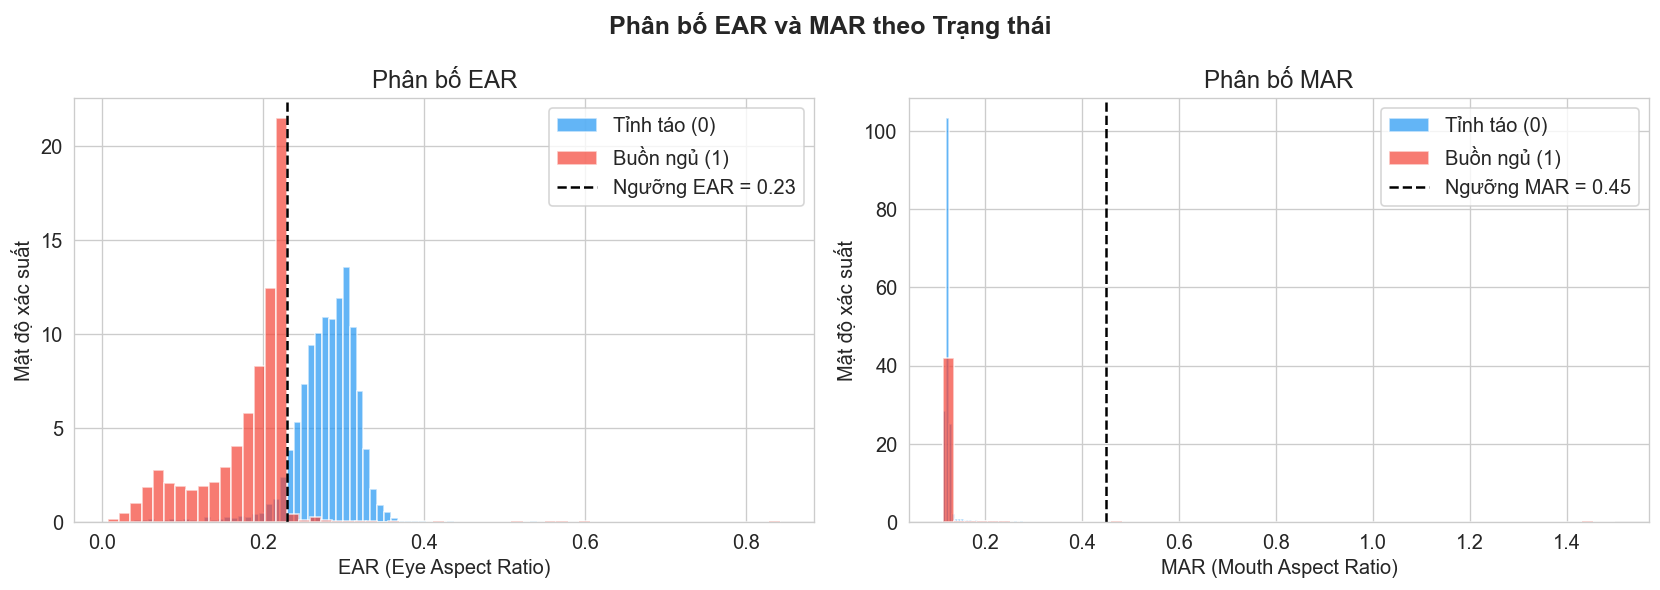

Lưu: 01_histogram_EAR_MAR.png


In [5]:
df0 = df[df.Label == 0]
df1 = df[df.Label == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phân bố EAR và MAR theo Trạng thái', fontsize=15, fontweight='bold')

# EAR
axes[0].hist(df0['EAR'], bins=60, alpha=0.7, color='#2196F3', label='Tỉnh táo (0)', density=True)
axes[0].hist(df1['EAR'], bins=60, alpha=0.7, color='#F44336', label='Buồn ngủ (1)', density=True)
axes[0].axvline(x=0.23, color='black', linestyle='--', linewidth=1.5, label='Ngưỡng EAR = 0.23')
axes[0].set_xlabel('EAR (Eye Aspect Ratio)')
axes[0].set_ylabel('Mật độ xác suất')
axes[0].set_title('Phân bố EAR')
axes[0].legend()

# MAR
axes[1].hist(df0['MAR'], bins=60, alpha=0.7, color='#2196F3', label='Tỉnh táo (0)', density=True)
axes[1].hist(df1['MAR'], bins=60, alpha=0.7, color='#F44336', label='Buồn ngủ (1)', density=True)
axes[1].axvline(x=0.45, color='black', linestyle='--', linewidth=1.5, label='Ngưỡng MAR = 0.45')
axes[1].set_xlabel('MAR (Mouth Aspect Ratio)')
axes[1].set_ylabel('Mật độ xác suất')
axes[1].set_title('Phân bố MAR')
axes[1].legend()

plt.tight_layout()

output_dir = '../images'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

save_path = os.path.join(output_dir, '01_histogram_EAR_MAR.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

print('Lưu: 01_histogram_EAR_MAR.png')

### 2.2 Boxplot EAR và MAR theo nhãn

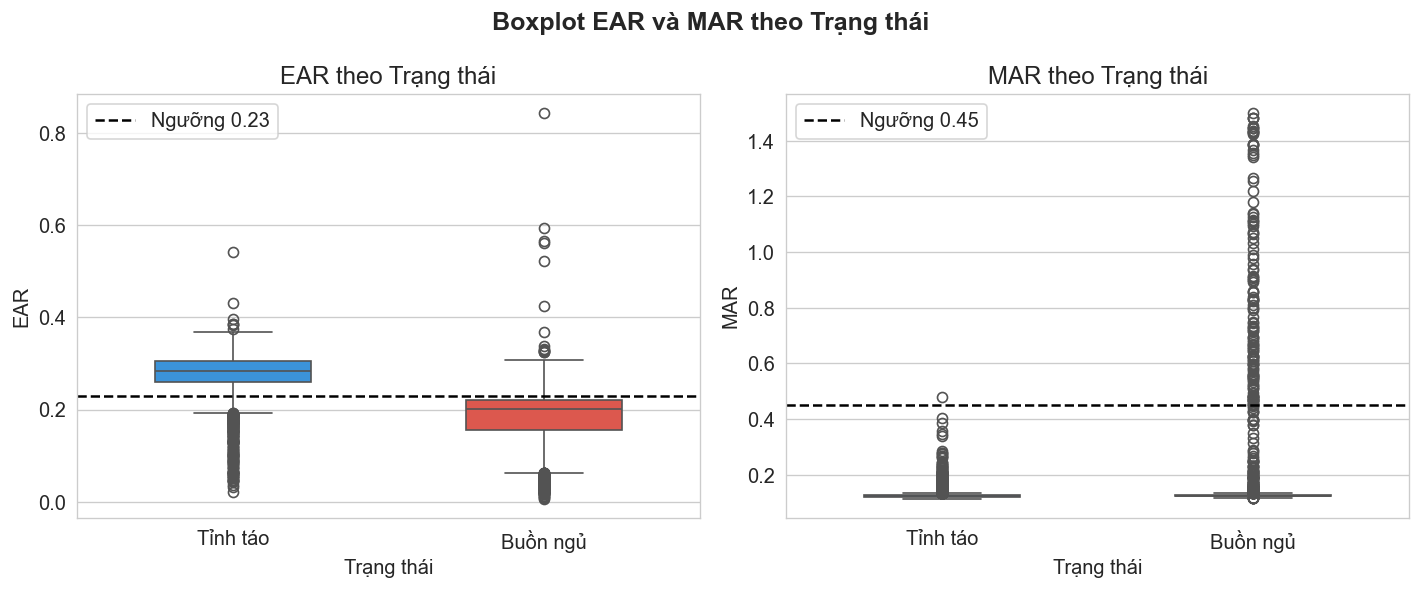

Lưu: ../images\02_boxplot_EAR_MAR.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Boxplot EAR và MAR theo Trạng thái', fontsize=15, fontweight='bold')

label_names = {0: 'Tỉnh táo', 1: 'Buồn ngủ'}
df_plot = df.copy()
df_plot['Trạng thái'] = df_plot['Label'].map(label_names)

sns.boxplot(data=df_plot, x='Trạng thái', y='EAR',
            palette={'Tỉnh táo': '#2196F3', 'Buồn ngủ': '#F44336'},
            ax=axes[0], width=0.5)
axes[0].axhline(y=0.23, color='black', linestyle='--', linewidth=1.5, label='Ngưỡng 0.23')
axes[0].set_title('EAR theo Trạng thái')
axes[0].legend()

sns.boxplot(data=df_plot, x='Trạng thái', y='MAR',
            palette={'Tỉnh táo': '#2196F3', 'Buồn ngủ': '#F44336'},
            ax=axes[1], width=0.5)
axes[1].axhline(y=0.45, color='black', linestyle='--', linewidth=1.5, label='Ngưỡng 0.45')
axes[1].set_title('MAR theo Trạng thái')
axes[1].legend()

plt.tight_layout()

output_dir = '../images'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

save_path = os.path.join(output_dir, '02_boxplot_EAR_MAR.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

print(f'Lưu: {save_path}')

### 2.3 Scatter Plot EAR vs MAR

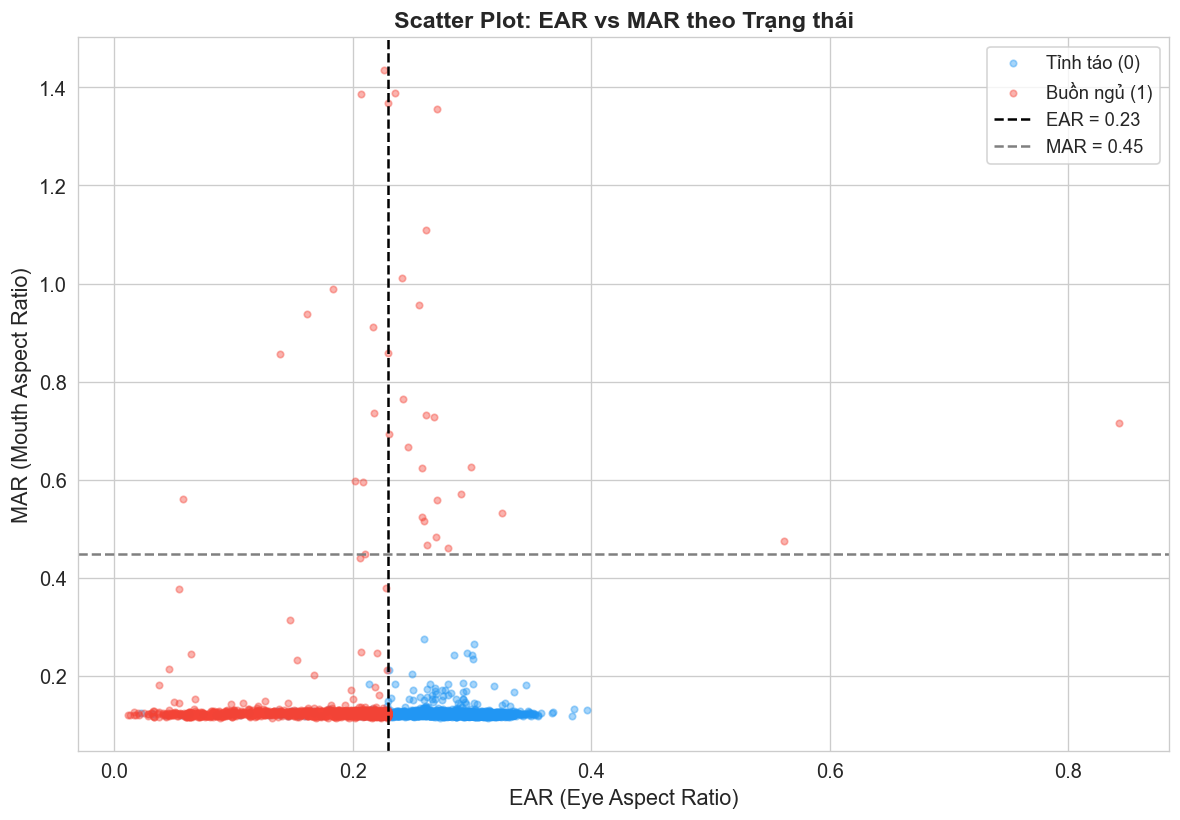

Lưu: ../images\03_scatter_EAR_MAR.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

sample0 = df0.sample(min(2000, len(df0)), random_state=42)
sample1 = df1.sample(min(2000, len(df1)), random_state=42)

ax.scatter(sample0['EAR'], sample0['MAR'], c='#2196F3', alpha=0.4, s=15, label='Tỉnh táo (0)')
ax.scatter(sample1['EAR'], sample1['MAR'], c='#F44336', alpha=0.4, s=15, label='Buồn ngủ (1)')

ax.axvline(x=0.23, color='black', linestyle='--', linewidth=1.5, label='EAR = 0.23')
ax.axhline(y=0.45, color='gray',  linestyle='--', linewidth=1.5, label='MAR = 0.45')

ax.set_xlabel('EAR (Eye Aspect Ratio)', fontsize=13)
ax.set_ylabel('MAR (Mouth Aspect Ratio)', fontsize=13)
ax.set_title('Scatter Plot: EAR vs MAR theo Trạng thái', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()

output_dir = '../images'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

save_path = os.path.join(output_dir, '03_scatter_EAR_MAR.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

print(f'Lưu: {save_path}')

---
## Bước 3 – Huấn luyện & So sánh Mô hình

### 3.1 Chuẩn bị dữ liệu Train/Test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {len(X_train):,} mẫu | Test: {len(X_test):,} mẫu')
print(f'Tỷ lệ nhãn train → 0: {(y_train==0).sum()} | 1: {(y_train==1).sum()}')
print(f'Tỷ lệ nhãn test  → 0: {(y_test==0).sum()}  | 1: {(y_test==1).sum()}')

Train: 11,973 mẫu | Test: 2,994 mẫu
Tỷ lệ nhãn train → 0: 5653 | 1: 6320
Tỷ lệ nhãn test  → 0: 1413  | 1: 1581


### 3.2 Huấn luyện 3 mô hình

In [ ]:
models = {
    'SVM (RBF)':      SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42),
    'Decision Tree':  DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':  RandomForestClassifier(n_estimators=250, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]
    cm = confusion_matrix(y_test, y_pred) 
    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_prob':   y_prob,
        'acc':      accuracy_score(y_test, y_pred),
        'f1':       f1_score(y_test, y_pred, average='weighted'),
        'precision':precision_score(y_test, y_pred, average='weighted'),
        'recall':   recall_score(y_test, y_pred, average='weighted'),
        'auc':      roc_auc_score(y_test, y_prob),
        'cm':       cm,
        'fp':       cm[0][1],
        'fn':       cm[1][0],
    }
    print(f'{name}: Acc={results[name]["acc"]*100:.2f}% | F1={results[name]["f1"]:.4f} | AUC={results[name]["auc"]:.4f}')

SVM (RBF): Acc=95.36% | F1=0.9534 | AUC=0.9657
Decision Tree: Acc=96.56% | F1=0.9655 | AUC=0.9734
Random Forest: Acc=95.59% | F1=0.9558 | AUC=0.9698


### 3.3 Bảng so sánh chi tiết

In [27]:
summary = pd.DataFrame({
    'Mô hình':    list(results.keys()),
    'Accuracy':   [f"{r['acc']*100:.2f}%" for r in results.values()],
    'Precision':  [f"{r['precision']:.4f}" for r in results.values()],
    'Recall':     [f"{r['recall']:.4f}" for r in results.values()],
    'F1-Score':   [f"{r['f1']:.4f}" for r in results.values()],
    'AUC-ROC':    [f"{r['auc']:.4f}" for r in results.values()],
    'FP':         [r['fp'] for r in results.values()],
    'FN':         [r['fn'] for r in results.values()],
})
print('\n📊 BẢNG SO SÁNH CÁC MÔ HÌNH')
print('=' * 80)
print(summary.to_string(index=False))


📊 BẢNG SO SÁNH CÁC MÔ HÌNH
      Mô hình Accuracy Precision Recall F1-Score AUC-ROC  FP  FN
    SVM (RBF)   95.36%    0.9573 0.9536   0.9534  0.9657 139   0
Decision Tree   96.56%    0.9675 0.9656   0.9655  0.9734 101   2
Random Forest   95.59%    0.9567 0.9559   0.9558  0.9698  99  33
